# Mapping the SDGs Against Each Other

In this notebook I work with relational data, connecting different sustainable development goals into a graph and visualizing that in different ways: an edge list, a radial layout, a Kamada-Kawai graph, a Fruchterman-Reingold graph, and a circular layout. Here, I make the dataset myself using my own judgment about which SDGs are connected and how strongly. Someone else would probably make a different dataset.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

import matplotlib.patches as patches
import networkx as nx
import numpy as np

## Building the edge list

The edges themselves are not the focus of this study but rather the visualizations. I decided on the edges and their weights by gut feeling: "Is there a clear connection between these, and if so, how strong?" The clearer and stronger the connection, the higher the weight. Global partnerships are crucial for climate action, so that edge gets the maximum weight of 5. The one constraint was that every node should be connected to at least one other node.


In [2]:
EDGES = [
    (1, 2, 4), (1, 7, 4), (1, 13, 1), (2, 3, 4), (2, 6, 2), (2, 9, 3),
    (3, 4, 3), (3, 6, 5), (3, 17, 2), (4, 5, 1), (4, 6, 4), (4, 7, 3),
    (4, 9, 3), (4, 11, 4), (4, 13, 4), (5, 8, 2), (5, 9, 1), (5, 10, 4),
    (5, 16, 2), (7, 9, 4), (7, 11, 3), (7, 13, 4), (7, 14, 1), (7, 15, 2),
    (7, 17, 2), (8, 9, 3), (9, 11, 2), (9, 12, 4), (9, 13, 3), (9, 14, 1),
    (9, 15, 1), (9, 17, 2), (10, 16, 3), (12, 13, 5), (12, 15, 2),
    (13, 14, 4), (13, 15, 2), (13, 17, 5), (14, 15, 1), (14, 17, 3),
    (15, 17, 4),
]

edge_list = pd.DataFrame(EDGES, columns=["Source", "Target", "Weight"])

G = nx.from_pandas_edgelist(edge_list, "Source", "Target", edge_attr="Weight")
G.add_nodes_from(range(1, 18))  # keeps any unconnected goal in the drawing

weights = [d["Weight"] for _, _, d in G.edges(data=True)]

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
edge_list.head(10)

17 nodes, 41 edges


,Source,Target,Weight
0,1,2,4
1,1,7,4
2,1,13,1
3,2,3,4
4,2,6,2
5,2,9,3
6,3,4,3
7,3,6,5
8,3,17,2
9,4,5,1


In [9]:
# which goals do I treat as 'hubs'
degrees = pd.DataFrame({
    "connections": dict(G.degree()),
    "weighted": dict(G.degree(weight="Weight")),
}).sort_values("weighted", ascending=False)

degrees

,connections,weighted
13,8,28
9,11,27
7,8,23
4,7,22
17,6,18
3,4,14
2,4,13
15,6,12
6,3,11
12,3,11


In [4]:
def draw_network(G, pos, ax, caption=None):
    """Draw the SDG graph with edge width carrying weight."""
    nx.draw(
        G, pos, ax=ax,
        with_labels=True,
        node_color="lightgreen",
        node_size=1200,
        width=weights,
        edge_color="gray",
        alpha=0.8,
        font_weight="bold",
    )
    ax.add_patch(patches.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        edgecolor="black", fill=False, clip_on=False,
    ))
    if caption:
        ax.text(
            0.5, -0.05, caption, transform=ax.transAxes,
            ha="center", va="top", fontsize=16,
            bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="gray", alpha=0.5),
        )

## Radial layout

Radial layout is certainly not the optimal layout to visualize this data as the data clearly doesn't have a tree structure. NetworkX's shell layout is an ok choice here.

I chose SDG number 16 as the center node as this made the visualization the easiest to understand. The rings represent the shortest distance from the center node.

rings from SDG 16: [[16], [5, 10], [4, 8, 9], [2, 3, 6, 7, 11, 12, 13, 14, 15, 17], [1]]


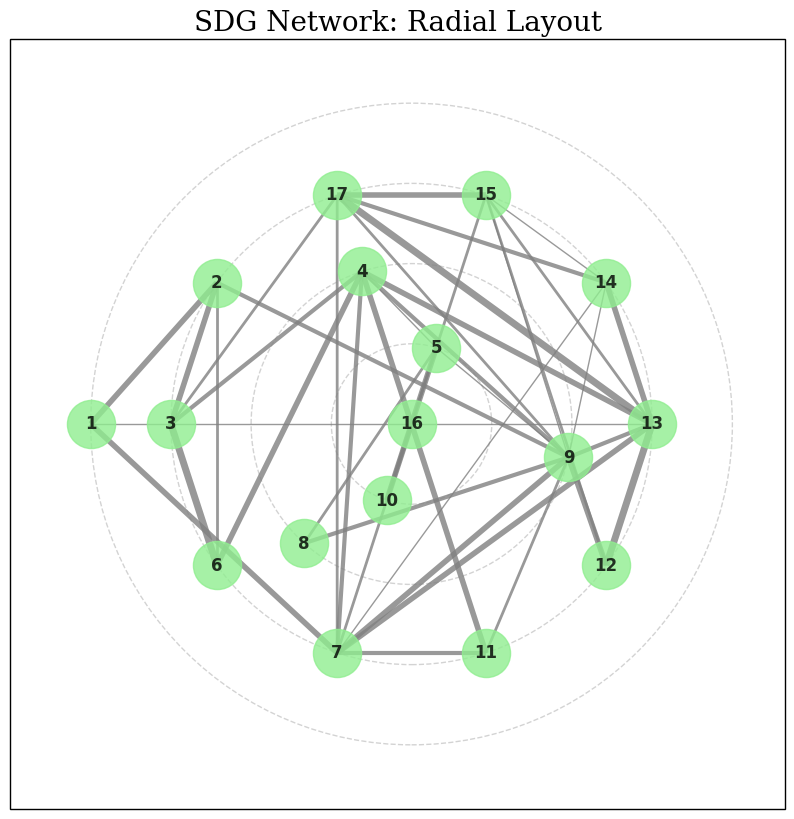

In [5]:
CENTRE = 16
distances = nx.single_source_shortest_path_length(G, CENTRE)

shells = [
    sorted(node for node, d in distances.items() if d == depth)
    for depth in sorted(set(distances.values()))
]
print("rings from SDG 16:", shells)

pos_radial = nx.shell_layout(G, nlist=shells)

fig, ax = plt.subplots(figsize=(10, 10))
draw_network(G, pos_radial, ax)

# ring lines
for radius in {round(float(np.linalg.norm(pos_radial[n])), 6) for n in G.nodes()}:
    if radius > 0:
        ax.add_patch(plt.Circle((0, 0), radius, color="lightgray",
                                fill=False, linestyle="--", zorder=0))

ax.axis("equal")
ax.margins(0.1)
plt.title("SDG Network: Radial Layout")
plt.savefig("../figures/08-radial-layout.png", dpi=150, bbox_inches="tight")
plt.show()

The one thing that this layout adds is that the rings show how many steps each goal is from SDG 16, whereas force-directed layouts only approximate distance. The problem is that ten of the seventeen goals are on the same ring, so the distance separates almost nothing and only SDG 1 ends up further away. Angular position has no meaning, and with 41 edges crossing the rings the figure takes a while to understand.

Not very happy with this one, so lesson learned: a radial layout needs a graph with a hierarchy. The circular layout below is better, because it doesn't force a structure that the data doesn't have.

## Kamada-Kawai

The Kamada-Kawai algorithm, much like the Fruchterman-Reingold algorithm, is a force-directed graph drawing method. It tries to make the distance between two nodes on the page match how many steps apart they are in the graph.

To create the Kamada-Kawai layouts, I went through multiple seeds to find ones where individual edges can be distinguished easily. With the seed, I created a random layout and used the positions of that layout as the initial positions in the Kamada-Kawai layout. Nodes and edges are the same as in the radial layout for the same reasons.


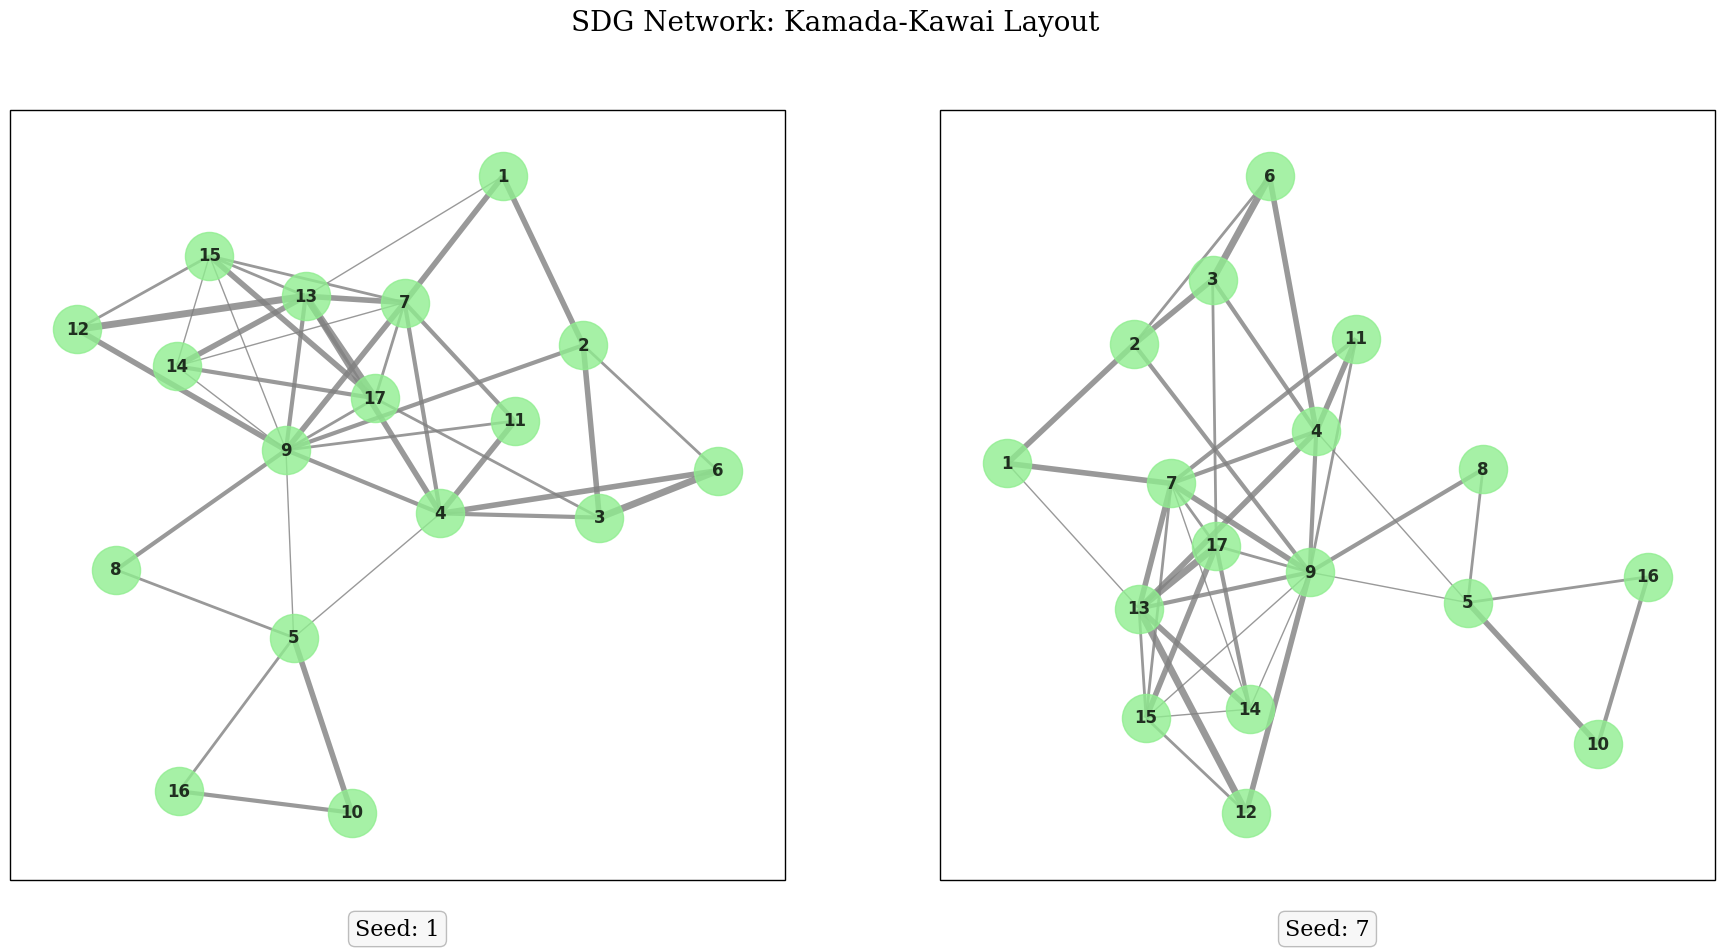

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

for ax, seed in zip(axes, [1, 7]):
    pos = nx.kamada_kawai_layout(G, pos=nx.random_layout(G, seed=seed))
    draw_network(G, pos, ax, caption=f"Seed: {seed}")

plt.suptitle("SDG Network: Kamada-Kawai Layout")
plt.savefig("../figures/08-kamada-kawai.png", dpi=150, bbox_inches="tight")
plt.show()

## Fruchterman-Reingold

Fruchterman-Reingold differs from Kamada-Kawai in that all nodes repel one another and every edge pulls its two nodes together, whereas Kamada-Kawai uses the shortest paths between all pairs to decide where nodes go.

As with the Kamada-Kawai layouts, I used two different seeds to create the Fruchterman-Reingold layouts. This time I passed the seed straight to the layout function instead of building a random layout first, since it generates its own starting positions.


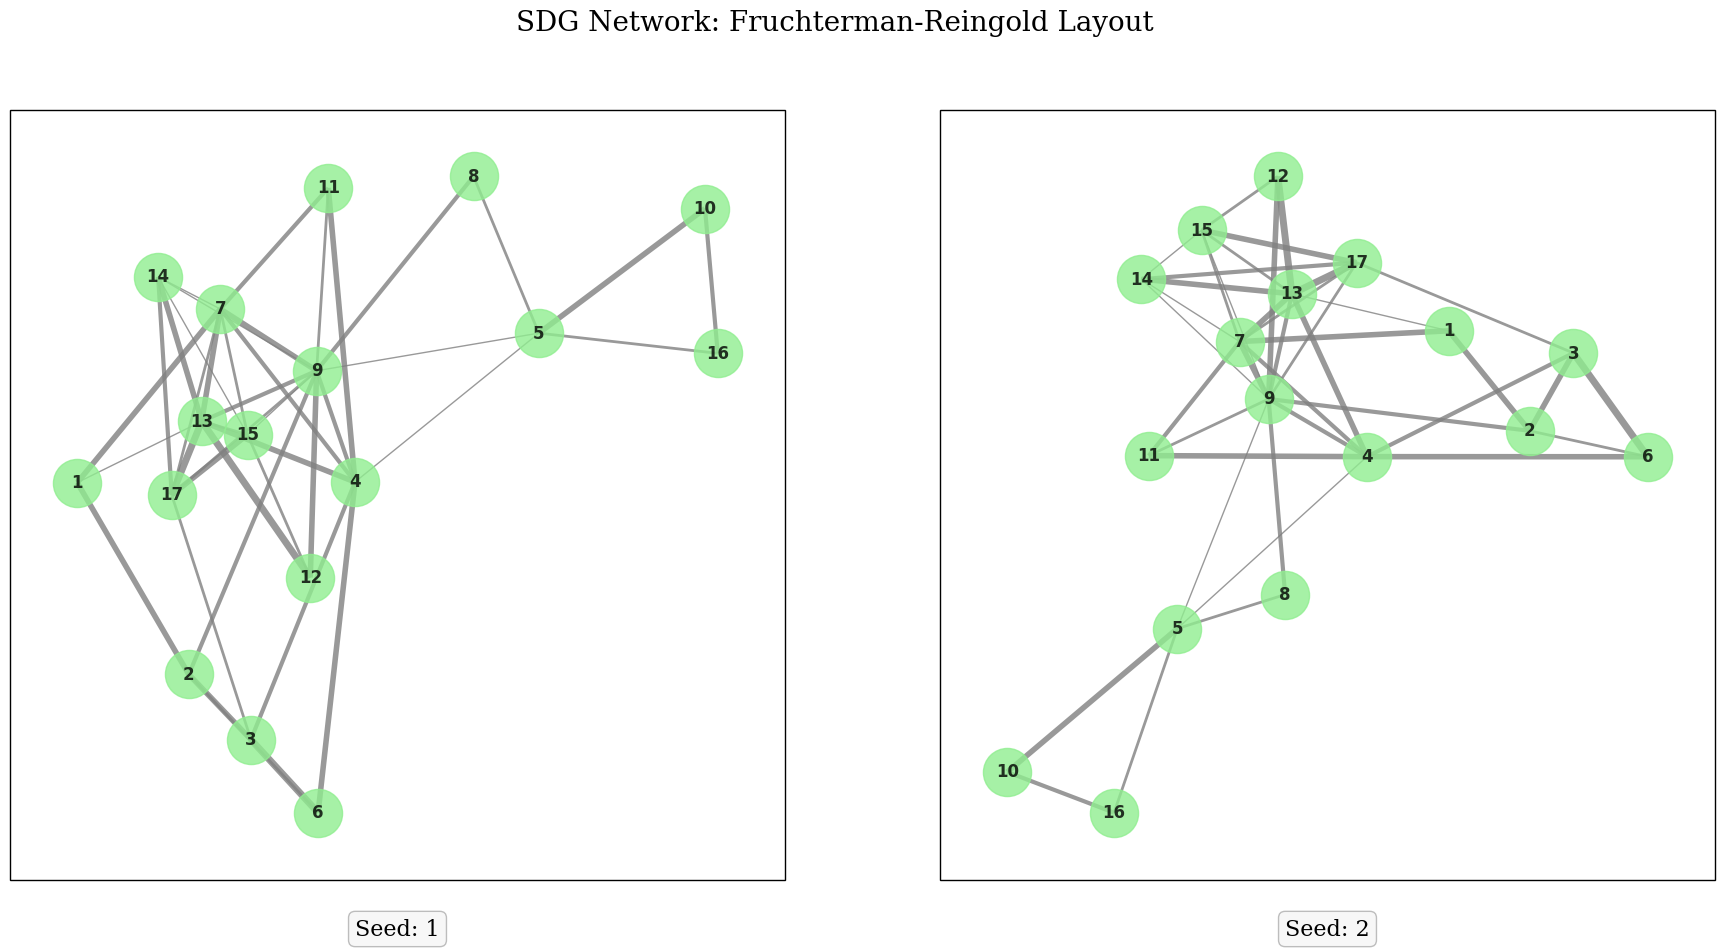

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

for ax, seed in zip(axes, [1, 2]):
    pos = nx.fruchterman_reingold_layout(G, seed=seed)
    draw_network(G, pos, ax, caption=f"Seed: {seed}")

plt.suptitle("SDG Network: Fruchterman-Reingold Layout")
plt.savefig("../figures/08-fruchterman-reingold.png", dpi=150, bbox_inches="tight")
plt.show()

## Circular layout

Compared to radial layout, circular layout is much more straightforward and 'honest' about the data. All edges can also be distinguished. It's not the most informative graph but it's simple enough that anyone understands how to read it. Position doesn't mean anything, and only the edges carry information.


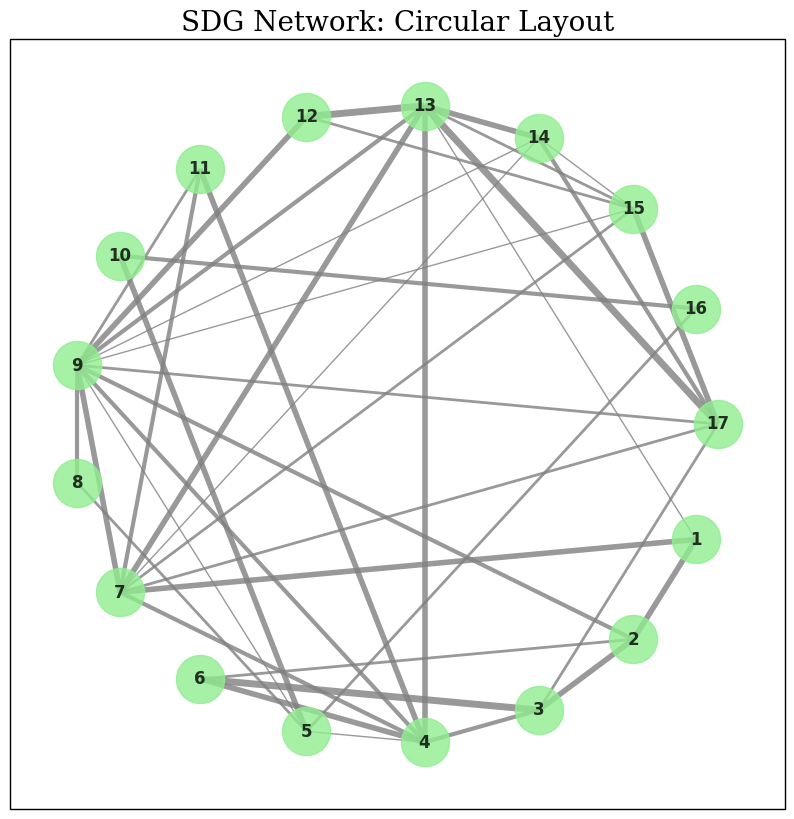

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
draw_network(G, nx.circular_layout(sorted(G.nodes())[::-1]), ax)
plt.title("SDG Network: Circular Layout")
plt.savefig("../figures/08-circular-layout.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparison & results

SDG 13 and SDG 9 are the 'hubs' of my graph: 13 has 8 connections with a total weight of 28, and 9 has 11 connections with a total weight of 27. Both end up in the middle of every force-directed layout, but that isn't really a finding as those layouts pull nodes with many edges inward. SDG 16 stays on the edge with its 2 connections, which is why it worked well as the center of the radial layout. Changing the seed moves nodes around but doesn't change which goals are central.

Since I made the edges myself, this says more about how I see the goals than about the goals. I connected climate action and infrastructure to almost everything and left peace and justice nearly on its own.

**Design notes**: edge width represents weight, so that the most important connections can be distinguished the quickest. Nodes are light green and slightly transparent so they don't completely cover the edges. Labels are numbers and every node has the same color as there's not much that color could add.
